# TikTok Viral Prediction — EDA (Full Data)

**Author:** Nouf Alharbi  
**Date:** 2026-09-21  
**Competition:** [In-class Competition: Predictive Modelling](https://www.kaggle.com/competitions/predictive-modelling-ds)

---

## Objective
Predict the cumulative view count at Day 30 for TikTok videos, using only early engagement metrics from Days 0–5.

## Evaluation Metric
**RMSE** — Root Mean Squared Error

## Dataset (Full)
- `videos.parquet` — 209,543 videos × 33 columns (metadata + text)
- `engagement_daily.parquet` — 6,068,955 rows (days 0–30)
- `creator_daily.parquet` — 278,433 rows (creator stats)

**Note:** Original dataset has 6M+ rows. We use the full version.

**Text features** (`desc`, `transcript`, `gpt_summary`, `hashtags`, `music_title`, `music_album`, `sticker_text`) are **removed** per competition rules.

## Data Split Strategy
- **Train**: videos with day-30 target (~74k videos)
- **Validation**: cross-validation on train
- **Test**: Kaggle hidden test set

## Workflow
1. Load and explore full data
2. Build target from engagement (day 30)
3. Filter engagement to days 0–5 (no leakage)
4. EDA and visualization
5. Feature engineering
6. Model training (2-Stage approach)
7. Submission

In [2]:
# ============================================
# Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load FULL data
base = "hf://datasets/lingbow/tiktok-video-engagement-200k"

videos_full = pd.read_parquet(f"{base}/videos.parquet")
engagement_full = pd.read_parquet(f"{base}/engagement_daily.parquet")
creators_full = pd.read_parquet(f"{base}/creator_daily.parquet")

print(f"Videos: {videos_full.shape}")
print(f"Engagement: {engagement_full.shape}")
print(f"Creators: {creators_full.shape}")

Videos: (209543, 33)
Engagement: (6068955, 10)
Creators: (278433, 7)


In [8]:
# ============================================
# STEP 1: EXPLORE + BUILD TARGET
# ============================================
print("=" * 60)
print("STEP 1: EXPLORE DATA + BUILD TARGET")
print("=" * 60)

# === 1. Videos info ===
print("\n--- VIDEOS ---")
print(f"Shape: {videos_full.shape}")
print(f"Columns: {list(videos_full.columns)}")
print(f"Has target? {'target_day30_views' in videos_full.columns}")
print(f"\nSample:")
display(videos_full.head(3))

# === 2. Engagement info ===
print("\n--- ENGAGEMENT ---")
print(f"Shape: {engagement_full.shape}")
print(f"Days range: {engagement_full['days_since_post'].min()} - {engagement_full['days_since_post'].max()}")
print(f"\nDays distribution (first/last):")
days_dist = engagement_full['days_since_post'].value_counts().sort_index()
print(f"First 6 days:\n{days_dist.head(6)}")
print(f"Last 3 days:\n{days_dist.tail(3)}")

# === 3. Check if day 30 exists ===
has_day30 = 30 in engagement_full['days_since_post'].values
print(f"\nHas day 30? {has_day30}")

# === 4. Build target ===
print("\n--- BUILDING TARGET ---")
target_full = engagement_full[engagement_full['days_since_post'] == 30] \
    .groupby('video_id')['play_count'].last().reset_index()
target_full.columns = ['video_id', 'target_day30_views']

print(f"Videos with day-30 target: {target_full.shape[0]:,}")

# === 5. Merge ===
df_full = videos_full.merge(target_full, on='video_id', how='inner')
print(f"Videos after merge: {df_full.shape}")

# === 6. Check target stats ===
print(f"\nTarget stats:")
print(df_full['target_day30_views'].describe())

# === 7. Creators info ===
print("\n--- CREATORS ---")
print(f"Shape: {creators_full.shape}")
print(f"Columns: {list(creators_full.columns)}")

STEP 1: EXPLORE DATA + BUILD TARGET

--- VIDEOS ---
Shape: (209543, 33)
Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'desc', 'sticker_text', 'hashtags', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_album', 'music_author', 'music_owner_id', 'music_id', 'music_title', 'transcript', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'gpt_summary', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']
Has target? False

Sample:


,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,desc,sticker_text,hashtags,created_by_ai,is_ads,music_selected_from,music_album,music_author,music_owner_id,music_id,music_title,transcript,word_count,emoji_count,question_count,hashtag_count,speaking_rate,gpt_summary,topic,anger,joy,surprise,sadness,disgust,fear
0,7386493327656504607,6958316329012003846,2024-06-30 21:46:54,2024-06-30,20.067,540p,un,0,#fallowme #foryoupage #fyp #fypp #goodengery #...,NaN,"[{'hashtag_id': '13497', 'hashtag_name': 'good...",0.0,0,edit_page_list,Nasty,Tinashe,NaN,7353374941268363265,Nasty,NaN,0.0,0.0,0.0,14.0,0.000000,"In this short video, the creator is seen in a ...",Lifestyle,0.007287,0.427565,0.004642,0.011638,0.154876,0.001623
1,7386314758808522014,6958316329012003846,2024-06-30 10:14:14,2024-06-30,83.100,540p,un,0,#fyp #foryoupage #fallowme #TikTokShop #newdro...,new drop coming,"[{'hashtag_id': '152178', 'hashtag_name': 'sho...",0.0,0,edit_page_list,Nasty,Tinashe,NaN,7353374941268363265,Nasty,NaN,3.0,0.0,0.0,7.0,0.000000,The video showcases a vibrant collection of un...,Beauty_Fashion,0.003728,0.850722,0.009022,0.003120,0.008401,0.000587
2,7387143945744141599,6958316329012003846,2024-07-02 15:51:42,2024-07-02,26.634,540p,un,0,#goodengery #packages #sample #mail #fyppppppp...,NaN,"[{'hashtag_id': '1649139584636934', 'hashtag_n...",0.0,0,original,NaN,MommaTata,6958316329012003846,7387144018116758303,original sound - mommatata420,when you go to the mail thinking that you only...,0.0,0.0,0.0,5.0,5.894721,"In this short video, the creator humorously re...",Life_hacks_Personal_growth,0.318762,0.197186,0.013447,0.051367,0.118099,0.000834



--- ENGAGEMENT ---
Shape: (6068955, 10)
Days range: 0 - 30

Days distribution (first/last):
First 6 days:
days_since_post
0    157065
1    206222
2    206193
3    206041
4    206012
5    206023
Name: count, dtype: int64
Last 3 days:
days_since_post
28    193465
29    193665
30     73940
Name: count, dtype: int64

Has day 30? True

--- BUILDING TARGET ---
Videos with day-30 target: 73,940
Videos after merge: (73940, 34)

Target stats:
count    7.394000e+04
mean     3.259884e+04
std      3.241677e+05
min      0.000000e+00
25%      3.420000e+02
50%      6.700000e+02
75%      2.916000e+03
max      2.065326e+07
Name: target_day30_views, dtype: float64

--- CREATORS ---
Shape: (278433, 7)
Columns: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count', 'enterprise_verified']


In [9]:
# ============================================
# STEP 2: BUILD TARGET + FILTER
# ============================================
print("=" * 60)
print("STEP 2: BUILD TARGET + FILTER")
print("=" * 60)

# === 1. Build target ===
print("\n--- BUILDING TARGET ---")
target_full = engagement_full[engagement_full['days_since_post'] == 30] \
    .groupby('video_id')['play_count'].last().reset_index()
target_full.columns = ['video_id', 'target_day30_views']

print(f"Videos with day-30 target: {target_full.shape[0]:,}")

# === 2. Merge ===
df_full = videos_full.merge(target_full, on='video_id', how='inner')
print(f"Videos after merge: {df_full.shape}")

# === 3. Target stats ===
print(f"\nTarget stats:")
print(df_full['target_day30_views'].describe())

print(f"\nSkewness: {df_full['target_day30_views'].skew():.3f}")
print(f"Kurtosis: {df_full['target_day30_views'].kurtosis():.3f}")

# === 4. Filter engagement (days 0-5) ===
print("\n--- FILTERING ENGAGEMENT (0-5) ---")
engagement = engagement_full[engagement_full['days_since_post'] <= 5].copy()
print(f"Full engagement: {engagement_full.shape}")
print(f"Filtered (0-5):  {engagement.shape}")

# === 5. Filter engagement to videos with target ===
engagement = engagement[engagement['video_id'].isin(df_full['video_id'])].copy()
print(f"Engagement for target videos: {engagement.shape}")

# === 6. Drop text features ===
print("\n--- DROPPING TEXT FEATURES ---")
text_cols = ['desc', 'sticker_text', 'hashtags', 'music_album', 
             'music_title', 'transcript', 'gpt_summary']
drop_cols = [c for c in text_cols if c in df_full.columns]
df_full = df_full.drop(columns=drop_cols)

print(f"Dropped: {drop_cols}")
print(f"df_full shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")

# === 7. Creators info ===
print("\n--- CREATORS ---")
print(f"Shape: {creators_full.shape}")
print(f"Columns: {list(creators_full.columns)}")
print(f"\nenterprise_verified non-null: {creators_full['enterprise_verified'].notna().sum()}")

STEP 2: BUILD TARGET + FILTER

--- BUILDING TARGET ---
Videos with day-30 target: 73,940
Videos after merge: (73940, 34)

Target stats:
count    7.394000e+04
mean     3.259884e+04
std      3.241677e+05
min      0.000000e+00
25%      3.420000e+02
50%      6.700000e+02
75%      2.916000e+03
max      2.065326e+07
Name: target_day30_views, dtype: float64

Skewness: 30.380
Kurtosis: 1314.485

--- FILTERING ENGAGEMENT (0-5) ---
Full engagement: (6068955, 10)
Filtered (0-5):  (1187556, 10)
Engagement for target videos: (391587, 10)

--- DROPPING TEXT FEATURES ---
Dropped: ['desc', 'sticker_text', 'hashtags', 'music_album', 'music_title', 'transcript', 'gpt_summary']
df_full shape: (73940, 27)
Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'a

In [10]:
# ============================================
# STEP 3: FINAL CLEANUP + MERGE
# ============================================
print("=" * 60)
print("STEP 3: FINAL CLEANUP + MERGE")
print("=" * 60)

# === 1. Filter engagement to only target videos ===
print("\n--- Filtering engagement ---")
engagement = engagement[engagement['video_id'].isin(df_full['video_id'])].copy()
print(f"Engagement for target videos: {engagement.shape}")
print(f"Unique videos in engagement: {engagement['video_id'].nunique():,}")

# === 2. Drop enterprise_verified ===
creators_full = creators_full.drop(columns=['enterprise_verified'])
print(f"\nCreators columns: {list(creators_full.columns)}")

# === 3. Rename for consistency ===
train = df_full.copy()
creators = creators_full.copy()
engagement_clean = engagement.copy()

print(f"\n--- READY ---")
print(f"train:     {train.shape}")
print(f"engagement: {engagement_clean.shape}")
print(f"creators:   {creators.shape}")

# === 4. Check missing values in train ===
print("\n--- Missing values in train ---")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# === 5. Check engagement days ===
print("\n--- Engagement days ---")
print(engagement_clean['days_since_post'].value_counts().sort_index())

STEP 3: FINAL CLEANUP + MERGE

--- Filtering engagement ---
Engagement for target videos: (391587, 10)
Unique videos in engagement: 73,922

Creators columns: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count']

--- READY ---
train:     (73940, 27)
engagement: (391587, 10)
creators:   (278433, 6)

--- Missing values in train ---
question_count         25596
emoji_count            25596
word_count             25596
speaking_rate          25596
hashtag_count          25596
music_owner_id         18179
music_selected_from      685
surprise                 317
sadness                  317
anger                    317
joy                      317
disgust                  317
fear                     317
music_author             116
music_id                   3
dtype: int64

--- Engagement days ---
days_since_post
0    27867
1    72622
2    72647
3    72660
4    73204
5    72587
Name: count, dtype: int64


TARGET: target_day30_views

Basic Statistics:
count    7.394000e+04
mean     3.259884e+04
std      3.241677e+05
min      0.000000e+00
25%      3.420000e+02
50%      6.700000e+02
75%      2.916000e+03
max      2.065326e+07
Name: target_day30_views, dtype: float64

Skewness: 30.380
Kurtosis: 1314.485


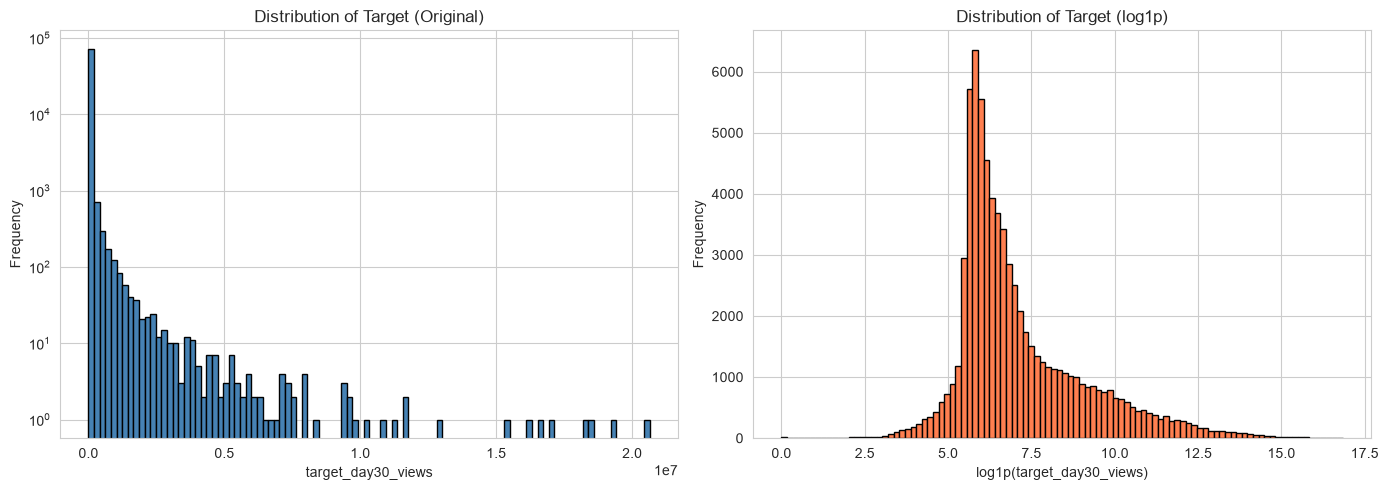


Top 10 values:
73659    20653259
73658    19216644
73666    18460546
42826    18306625
43160    17128934
61079    16616294
69492    16310546
6861     15319308
6818     12927041
73635    11717212
Name: target_day30_views, dtype: int64

Top 10 as % of sum:  6.91%
Top 100 as % of sum: 28.57%
Top 1000 as % of sum: 69.45%


In [11]:
# ============================================
# EDA 1: TARGET ANALYSIS (FULL DATA)
# ============================================
print("=" * 60)
print("TARGET: target_day30_views")
print("=" * 60)

print("\nBasic Statistics:")
print(train['target_day30_views'].describe())

print(f"\nSkewness: {train['target_day30_views'].skew():.3f}")
print(f"Kurtosis: {train['target_day30_views'].kurtosis():.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['target_day30_views'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Target (Original)')
axes[0].set_xlabel('target_day30_views')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

axes[1].hist(np.log1p(train['target_day30_views']), bins=100, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Target (log1p)')
axes[1].set_xlabel('log1p(target_day30_views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Top values
print("\nTop 10 values:")
print(train['target_day30_views'].sort_values(ascending=False).head(10))

y_sorted = train['target_day30_views'].sort_values(ascending=False)
print(f"\nTop 10 as % of sum:  {y_sorted.head(10).sum() / y_sorted.sum() * 100:.2f}%")
print(f"Top 100 as % of sum: {y_sorted.head(100).sum() / y_sorted.sum() * 100:.2f}%")
print(f"Top 1000 as % of sum: {y_sorted.head(1000).sum() / y_sorted.sum() * 100:.2f}%")

In [12]:
# ============================================
# EDA 2: ENGAGEMENT ANALYSIS (FULL DATA)
# ============================================
print("=" * 60)
print("ENGAGEMENT ANALYSIS")
print("=" * 60)

# === 1. Days distribution ===
print("\nDays since post distribution:")
print(engagement['days_since_post'].value_counts().sort_index())

# === 2. Unique videos ===
n_eng = engagement['video_id'].nunique()
n_train = train['video_id'].nunique()
print(f"\nUnique videos in engagement: {n_eng:,}")
print(f"Unique videos in train:      {n_train:,}")
print(f"Coverage: {n_eng/n_train*100:.1f}%")

# === 3. Rows per video ===
rows_per_video = engagement.groupby('video_id').size()
print(f"\nRows per video:")
print(rows_per_video.describe())

# === 4. Engagement metrics stats ===
print("\n" + "=" * 60)
print("ENGAGEMENT METRICS STATS")
print("=" * 60)
print(engagement[['play_count', 'like_count', 'comment_count', 
                  'share_count', 'collect_count', 'download_count', 
                  'whatsapp_share_count']].describe().T)

# === 5. Check day 0 missing ===
print("\n" + "=" * 60)
print("DAY 0 CHECK")
print("=" * 60)
day0_count = (engagement['days_since_post'] == 0).sum()
print(f"Day 0 rows: {day0_count:,}")
print(f"Videos with day 0: {engagement[engagement['days_since_post']==0]['video_id'].nunique():,}")

ENGAGEMENT ANALYSIS

Days since post distribution:
days_since_post
0    27867
1    72622
2    72647
3    72660
4    73204
5    72587
Name: count, dtype: int64

Unique videos in engagement: 73,922
Unique videos in train:      73,940
Coverage: 100.0%

Rows per video:
count    73922.000000
mean         5.297300
std          0.554997
min          1.000000
25%          5.000000
50%          5.000000
75%          6.000000
max          6.000000
dtype: float64

ENGAGEMENT METRICS STATS
                         count          mean            std  min    25%    50%     75%         max
play_count            391587.0  14546.875290  156509.977024  0.0  273.0  456.0  1394.0  16487108.0
like_count            391587.0   1418.517905   16759.643177  0.0   14.0   36.0   101.0   1778036.0
comment_count         391587.0     23.331827     232.641420  0.0    0.0    2.0     8.0     31600.0
share_count           391587.0    110.123286    2802.051400  0.0    0.0    0.0     2.0    307472.0
collect_count         

In [13]:
# ============================================
# EDA 3: CREATORS ANALYSIS (FULL DATA)
# ============================================
print("=" * 60)
print("CREATORS ANALYSIS")
print("=" * 60)

# === 1. Overview ===
print(f"Unique creators: {creators['author_id'].nunique():,}")
print(f"Date range: {creators['date'].min()} to {creators['date'].max()}")

# === 2. Rows per creator ===
rows_per_creator = creators.groupby('author_id').size()
print(f"\nRows per creator:")
print(rows_per_creator.describe())

# === 3. Creator stats ===
print("\n" + "=" * 60)
print("CREATOR STATS")
print("=" * 60)
print(creators[['follower_count', 'following_count', 
                'total_favorited', 'video_count']].describe().T)

# === 4. Check missing ===
print("\nMissing values:")
print(creators.isnull().sum())

# === 5. Merge with train ===
print("\n" + "=" * 60)
print("MERGE WITH TRAIN")
print("=" * 60)

creators_agg = creators.sort_values(['author_id', 'date']).groupby('author_id').agg({
    'follower_count': 'last',
    'following_count': 'last',
    'total_favorited': 'last',
    'video_count': 'last'
}).reset_index()

merged = train.merge(creators_agg, on='author_id', how='left')
print(f"Train: {train.shape}")
print(f"After merge: {merged.shape}")
print(f"Missing follower_count: {merged['follower_count'].isnull().sum():,}")

CREATORS ANALYSIS
Unique creators: 1,872
Date range: 2024-06-24 to 2024-12-09

Rows per creator:
count    1872.000000
mean      148.735577
std        19.752424
min        46.000000
25%       148.000000
50%       157.000000
75%       160.000000
max       161.000000
dtype: float64

CREATOR STATS
                    count          mean           std    min      25%       50%        75%           max
follower_count   278256.0  1.237307e+05  8.235605e+05  897.0   3421.0   10149.0    38047.0  2.832410e+07
following_count  278256.0  1.957407e+03  2.637722e+03    0.0    287.0     747.0     2408.0  1.000000e+04
total_favorited  278433.0  4.770185e+06  3.128869e+07    0.0  44178.0  219083.0  1216020.0  1.036572e+09
video_count      278406.0  9.389706e+02  1.034695e+03    0.0    331.0     632.0     1199.0  1.997400e+04

Missing values:
author_id            0
date                 0
follower_count     177
following_count    177
total_favorited      0
video_count         27
dtype: int64

MERGE WITH 

In [14]:
# ============================================
# CORRELATION + PIVOT
# ============================================
print("=" * 60)
print("CORRELATION WITH TARGET")
print("=" * 60)

# === 1. Aggregate engagement per video ===
eng_agg = engagement.groupby('video_id').agg({
    'days_since_post': 'max',
    'play_count': 'last',
    'like_count': 'last',
    'comment_count': 'last',
    'share_count': 'last',
    'collect_count': 'last',
    'download_count': 'last',
    'whatsapp_share_count': 'last'
}).reset_index()

eng_agg.columns = ['video_id', 'max_day', 
                   'play_last', 'like_last', 'comment_last',
                   'share_last', 'collect_last', 'download_last', 
                   'whatsapp_last']

# === 2. Merge with train ===
merged = train.merge(eng_agg, on='video_id', how='left')
print(f"Merged: {merged.shape}")
print(f"Missing play_last: {merged['play_last'].isnull().sum()}")

# === 3. Correlation ===
numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['video_id', 'author_id']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_with_target = merged[numeric_cols].corr()['target_day30_views'].drop('target_day30_views').sort_values(ascending=False)

print("\nTop 15 Positive Correlations:")
print(corr_with_target.head(15))

# === 4. Pivot engagement ===
def pivot_metric(df, metric_name):
    pivot = df.pivot_table(
        index='video_id', columns='days_since_post', 
        values=metric_name, aggfunc='first'
    )
    pivot.columns = [f'{metric_name}_day{c}' for c in pivot.columns]
    return pivot

metrics = ['play_count', 'like_count', 'comment_count', 
           'share_count', 'collect_count', 'download_count', 
           'whatsapp_share_count']

pivoted_dfs = [pivot_metric(engagement, m) for m in metrics]
engagement_pivot = pd.concat(pivoted_dfs, axis=1).reset_index()

print(f"\nPivoted shape: {engagement_pivot.shape}")

# Check missing days
print("\nMissing per day:")
for col in ['play_count_day1', 'play_count_day3', 'play_count_day5']:
    print(f"  {col}: {engagement_pivot[col].isnull().sum():,}")

CORRELATION WITH TARGET
Merged: (73940, 35)
Missing play_last: 18

Top 15 Positive Correlations:
play_last         0.911215
like_last         0.818426
collect_last      0.660293
share_last        0.619671
comment_last      0.504402
whatsapp_last     0.443522
download_last     0.415266
question_count    0.066312
word_count        0.063493
is_english        0.051844
speaking_rate     0.040727
duration          0.030120
surprise          0.013935
sadness           0.008643
emoji_count       0.004823
Name: target_day30_views, dtype: float64

Pivoted shape: (73922, 43)

Missing per day:
  play_count_day1: 1,300
  play_count_day3: 1,262
  play_count_day5: 1,335


In [15]:
# ============================================
# FEATURE ENGINEERING: ENGAGEMENT FEATURES
# ============================================
print("=" * 60)
print("BUILDING ENGAGEMENT FEATURES")
print("=" * 60)

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), 0, a / b)

feat = engagement_pivot[['video_id']].copy()

# === 1. Play features ===
feat['play_last'] = engagement_pivot['play_count_day5']
feat['play_first'] = engagement_pivot['play_count_day1']
feat['play_max'] = engagement_pivot[[f'play_count_day{i}' for i in range(1,6)]].max(axis=1)
feat['play_mean'] = engagement_pivot[[f'play_count_day{i}' for i in range(1,6)]].mean(axis=1)
feat['play_std'] = engagement_pivot[[f'play_count_day{i}' for i in range(1,6)]].std(axis=1)

# Growth ratios
feat['play_growth_5_1'] = safe_divide(engagement_pivot['play_count_day5'], engagement_pivot['play_count_day1'])
feat['play_growth_5_3'] = safe_divide(engagement_pivot['play_count_day5'], engagement_pivot['play_count_day3'])
feat['play_growth_3_1'] = safe_divide(engagement_pivot['play_count_day3'], engagement_pivot['play_count_day1'])

# Daily differences
feat['play_diff_5_4'] = engagement_pivot['play_count_day5'] - engagement_pivot['play_count_day4']
feat['play_diff_4_3'] = engagement_pivot['play_count_day4'] - engagement_pivot['play_count_day3']
feat['play_diff_3_2'] = engagement_pivot['play_count_day3'] - engagement_pivot['play_count_day2']

# === 2. Interaction Ratios ===
for metric in ['like', 'comment', 'share', 'collect', 'download', 'whatsapp']:
    if metric == 'whatsapp':
        col = 'whatsapp_share_count_day5'
    else:
        col = f'{metric}_count_day5'
    feat[f'{metric}_ratio'] = safe_divide(engagement_pivot[col], engagement_pivot['play_count_day5'])

# === 3. Last-day metrics ===
feat['like_last'] = engagement_pivot['like_count_day5']
feat['comment_last'] = engagement_pivot['comment_count_day5']
feat['share_last'] = engagement_pivot['share_count_day5']
feat['collect_last'] = engagement_pivot['collect_count_day5']
feat['download_last'] = engagement_pivot['download_count_day5']
feat['whatsapp_last'] = engagement_pivot['whatsapp_share_count_day5']

# === 4. Total engagement ===
feat['total_engagement_last'] = (
    feat['like_last'] + feat['comment_last'] + feat['share_last'] +
    feat['collect_last'] + feat['download_last'] + feat['whatsapp_last']
)
feat['engagement_ratio'] = safe_divide(feat['total_engagement_last'], feat['play_last'])

print(f"Features built: {feat.shape[1] - 1}")
print(f"\nFeatures:")
print(list(feat.columns)[:15])
feat.head()

BUILDING ENGAGEMENT FEATURES
Features built: 25

Features:
['video_id', 'play_last', 'play_first', 'play_max', 'play_mean', 'play_std', 'play_growth_5_1', 'play_growth_5_3', 'play_growth_3_1', 'play_diff_5_4', 'play_diff_4_3', 'play_diff_3_2', 'like_ratio', 'comment_ratio', 'share_ratio']


,video_id,play_last,play_first,play_max,play_mean,play_std,play_growth_5_1,play_growth_5_3,play_growth_3_1,play_diff_5_4,play_diff_4_3,play_diff_3_2,like_ratio,comment_ratio,share_ratio,collect_ratio,download_ratio,whatsapp_ratio,like_last,comment_last,share_last,collect_last,download_last,whatsapp_last,total_engagement_last,engagement_ratio
0,7384086821132717358,478085.0,330084.0,478085.0,427834.0,65359.566151,1.448374,1.028445,1.408314,2699.0,10524.0,74109.0,0.098537,0.000299,0.012416,0.022981,0.000770,0.000071,47109.0,143.0,5936.0,10987.0,368.0,34.0,64577.0,0.135074
1,7384126510539558175,756.0,600.0,756.0,691.2,63.330088,1.260000,1.084648,1.161667,14.0,45.0,36.0,0.125661,0.013228,0.000000,0.006614,0.001323,0.000000,95.0,10.0,0.0,5.0,1.0,0.0,111.0,0.146825
2,7384175589206265118,557.0,323.0,557.0,441.4,90.588631,1.724458,1.246085,1.383901,65.0,45.0,59.0,0.034111,0.000000,0.000000,0.003591,0.000000,0.000000,19.0,0.0,0.0,2.0,0.0,0.0,21.0,0.037702
3,7384177529092951338,11743.0,11045.0,11743.0,11423.6,272.941935,1.063196,1.027384,1.034857,133.0,180.0,140.0,0.128247,0.006557,0.004598,0.004939,0.000085,0.000000,1506.0,77.0,54.0,58.0,1.0,0.0,1696.0,0.144426
4,7384192949644430622,5386.0,3306.0,5386.0,4491.2,804.231745,1.629159,1.175213,1.386267,375.0,428.0,413.0,0.062755,0.000557,0.000557,0.002599,0.000000,0.000000,338.0,3.0,3.0,14.0,0.0,0.0,358.0,0.066469


In [16]:
# ============================================
# MERGE ALL + ADVANCED FEATURES
# ============================================
print("=" * 60)
print("MERGING ALL DATASETS")
print("=" * 60)

# === 1. Start with train ===
df = train.copy()
print(f"Train: {df.shape}")

# === 2. Merge engagement features ===
df = df.merge(feat, on='video_id', how='left')
print(f"After engagement merge: {df.shape}")

# === 3. Aggregate creators ===
creators_agg = creators.sort_values(['author_id', 'date']).groupby('author_id').agg({
    'follower_count': 'last',
    'following_count': 'last',
    'total_favorited': 'last',
    'video_count': 'last'
}).reset_index()

# === 4. Merge creators ===
df = df.merge(creators_agg, on='author_id', how='left')
print(f"After creators merge: {df.shape}")

# === 5. Set index ===
df = df.set_index('video_id')
print(f"\nFinal shape: {df.shape}")

# === 6. Missing values ===
print(f"\nMissing values (top 10):")
missing = df.isnull().sum().sort_values(ascending=False).head(10)
print(missing)

# === 7. Add advanced features ===
print("\n--- ADVANCED FEATURES ---")
df_adv = df.copy()

# Time features
df_adv['create_time'] = pd.to_datetime(df_adv['create_time'])
df_adv['hour'] = df_adv['create_time'].dt.hour
df_adv['day_of_week'] = df_adv['create_time'].dt.dayofweek
df_adv['month'] = df_adv['create_time'].dt.month
df_adv['is_weekend'] = (df_adv['day_of_week'] >= 5).astype(int)

# Creator ratios
df_adv['follower_following_ratio'] = safe_divide(df_adv['follower_count'], df_adv['following_count'])
df_adv['favorited_per_video'] = safe_divide(df_adv['total_favorited'], df_adv['video_count'])
df_adv['play_to_follower'] = safe_divide(df_adv['play_last'], df_adv['follower_count'])
df_adv['play_to_favorited'] = safe_divide(df_adv['play_last'], df_adv['total_favorited'])

# Log transforms
for col in ['follower_count', 'total_favorited', 'video_count', 'play_last', 'play_mean']:
    df_adv[f'log_{col}'] = np.log1p(df_adv[col])

# Engagement diversity
eng_cols = ['like_last', 'comment_last', 'share_last', 'collect_last', 'download_last', 'whatsapp_last']
df_adv['engagement_diversity'] = (df_adv[eng_cols] > 0).sum(axis=1)

# Topic popularity
topic_stats = df_adv.groupby('topic')['target_day30_views'].agg(['mean', 'median', 'count'])
topic_stats.columns = ['topic_mean_views', 'topic_median_views', 'topic_count']
df_adv = df_adv.merge(topic_stats, on='topic', how='left')

# Interaction features
df_adv['play_x_like'] = df_adv['play_last'] * df_adv['like_ratio']
df_adv['play_x_share'] = df_adv['play_last'] * df_adv['share_ratio']
df_adv['log_play_x_follower'] = df_adv['log_play_last'] * df_adv['log_follower_count']

print(f"df_adv shape: {df_adv.shape}")
print(f"New features: {df_adv.shape[1] - df.shape[1]}")

MERGING ALL DATASETS
Train: (73940, 27)
After engagement merge: (73940, 52)
After creators merge: (73940, 56)

Final shape: (73940, 55)

Missing values (top 10):
hashtag_count     25596
emoji_count       25596
speaking_rate     25596
question_count    25596
word_count        25596
music_owner_id    18179
play_diff_3_2      2517
play_diff_5_4      2032
play_diff_4_3      1967
collect_last       1353
dtype: int64

--- ADVANCED FEATURES ---
df_adv shape: (73940, 75)
New features: 20


In [17]:
# ============================================
# PREPROCESSING
# ============================================
from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

# === 1. Prepare df for modeling ===
df_model = df_adv.copy()

# Drop useless columns
drop_cols = [
    'author_id', 'create_time', 'create_date',
    'music_owner_id', 'music_id',
    'target_day30_views',
    'topic',
]
drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

# === 2. Encode categoricals ===
cat_cols = df_model.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Categorical: {cat_cols}")

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('missing').astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# === 3. Fill NaN ===
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

# === 4. Target ===
y = df_adv['target_day30_views'].copy()
y_cbrt = np.cbrt(y)

# === 5. Sample weights ===
sample_weights = 1 / (1 + np.log1p(y))

# === 6. Bins for stratification ===
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

# === 7. Threshold for 2-stage ===
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

print(f"\nShape: {df_model.shape}")
print(f"Missing: {df_model.isnull().sum().sum()}")
print(f"\nTarget: median={y.median():,.0f}, mean={y.mean():,.0f}, max={y.max():,.0f}")
print(f"Viral threshold: {threshold:,.0f}")
print(f"Viral count: {is_viral.sum():,} ({is_viral.mean()*100:.1f}%)")

PREPROCESSING
Categorical: ['ratio', 'desc_language', 'is_ads', 'music_selected_from', 'music_author']

Shape: (73940, 68)
Missing: 0

Target: median=670, mean=32,599, max=20,653,259
Viral threshold: 21,598
Viral count: 7,394 (10.0%)


In [18]:
# ============================================
# FEATURE IMPORTANCE + SELECTION
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# === 1. Feature importance from classifier ===
clf_imp = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp.fit(df_model, is_viral)

imp_df = pd.DataFrame({
    'feature': df_model.columns,
    'importance': clf_imp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 30 Features:")
print(imp_df.head(30).to_string(index=False))

# === 2. 2-Stage Model ===
print("\n" + "=" * 60)
print("2-STAGE MODEL")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store OOF
oof = np.zeros(len(df_model))

# Use top 30
top_30 = imp_df.head(30)['feature'].tolist()
df_top30 = df_model[top_30]

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
    X_train = df_top30.iloc[train_idx].values
    X_val = df_top30.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # Classifier
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    # Regressor all
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # Regressor viral
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y_val, oof[val_idx]))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

# === 3. Final ===
final_rmse = np.sqrt(mean_squared_error(y.values, oof))
print("\n" + "=" * 60)
print(f"2-STAGE RMSE (Full Data): {final_rmse:,.0f}")
print(f"2-STAGE RMSE (Sample):    100,945")

FEATURE IMPORTANCE

Top 30 Features:
                 feature  importance
                play_max   19.052802
               play_last    8.424169
           play_diff_5_4    8.087602
           log_play_last    7.950469
           log_play_mean    6.841587
     log_play_x_follower    4.757037
           play_diff_3_2    2.676506
           play_diff_4_3    2.647333
                play_std    2.515066
         play_growth_5_3    2.426641
              like_ratio    2.239203
             video_count    2.224018
     favorited_per_video    2.167045
      log_follower_count    2.114722
               play_mean    2.089695
         log_video_count    2.052144
follower_following_ratio    1.937139
   total_engagement_last    1.824313
               like_last    1.691162
            collect_last    1.425950
     log_total_favorited    1.317981
          follower_count    1.228304
              play_first    1.109376
       play_to_favorited    0.875093
        play_to_follower    0.787638
 

In [19]:
# ============================================
# FIX DATA LEAKAGE + RERUN
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("FIX DATA LEAKAGE + RERUN")
print("=" * 60)

# === 1. Remove leaky features ===
leaky_cols = ['topic_mean_views', 'topic_median_views', 'topic_count']
df_model_fixed = df_model.drop(columns=[c for c in leaky_cols if c in df_model.columns])
print(f"Removed leaky: {leaky_cols}")
print(f"Shape: {df_model_fixed.shape}")

# === 2. Setup ===
y = df_adv['target_day30_views'].copy()
y_cbrt = np.cbrt(y)
sample_weights = 1 / (1 + np.log1p(y))
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# === 3. Feature importance ===
clf_imp = CatBoostClassifier(
    n_estimators=300, learning_rate=0.03, depth=4,
    l2_leaf_reg=1, random_state=42, verbose=0
)
clf_imp.fit(df_model_fixed, is_viral)

imp_df = pd.DataFrame({
    'feature': df_model_fixed.columns,
    'importance': clf_imp.feature_importances_
}).sort_values('importance', ascending=False)

top_30 = imp_df.head(30)['feature'].tolist()
df_top30 = df_model_fixed[top_30]

# === 4. 2-Stage Model ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(df_top30))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
    X_train = df_top30.iloc[train_idx].values
    X_val = df_top30.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # Classifier
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    # Regressor all
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # Regressor viral
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y_val, oof[val_idx]))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

final_rmse = np.sqrt(mean_squared_error(y.values, oof))
print("\n" + "=" * 60)
print(f"FIXED RMSE: {final_rmse:,.0f}")
print(f"Previous Full: 131,150")
print(f"Sample: 100,945")

FIX DATA LEAKAGE + RERUN
Removed leaky: ['topic_mean_views', 'topic_median_views', 'topic_count']
Shape: (73940, 65)
Fold 1: RMSE =    140,486
Fold 2: RMSE =    184,889
Fold 3: RMSE =    131,946
Fold 4: RMSE =     92,153
Fold 5: RMSE =     87,002

FIXED RMSE: 132,205
Previous Full: 131,150
Sample: 100,945


In [20]:
# ============================================
# IMPROVED FULL DATA MODEL
# ============================================
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

print("=" * 60)
print("IMPROVED FULL DATA MODEL")
print("=" * 60)

# === 1. Winsorization ===
print("\n--- WINSORIZATION ---")
q_high = y.quantile(0.999)
print(f"Original max: {y.max():,.0f}")
print(f"Q99.9: {q_high:,.0f}")

y_winsor = y.clip(upper=q_high)
print(f"Winsorized max: {y_winsor.max():,.0f}")

# === 2. Setup ===
y_cbrt = np.cbrt(y_winsor)

# Stronger sample weights
sample_weights = 1 / (1 + np.log1p(y)) ** 2   # ← أقوى

y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
threshold = y.quantile(0.90)
is_viral = (y >= threshold).astype(int)

# Use top 30 features
top_30 = imp_df.head(30)['feature'].tolist()
df_top30 = df_model_fixed[top_30]

# === 3. 2-Stage Model ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(df_top30))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_top30, y_bins), 1):
    X_train = df_top30.iloc[train_idx].values
    X_val = df_top30.iloc[val_idx].values
    
    y_train_orig = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    y_train_cbrt = y_cbrt.iloc[train_idx].values
    w_train = sample_weights.iloc[train_idx].values
    is_viral_train = is_viral.iloc[train_idx].values
    
    # Classifier
    clf = CatBoostClassifier(
        n_estimators=300, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    clf.fit(X_train, is_viral_train)
    proba = clf.predict_proba(X_val)[:, 1]
    
    # Regressor all
    reg_all = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_all.fit(X_train, y_train_cbrt, sample_weight=w_train)
    pred_all = reg_all.predict(X_val) ** 3
    
    # Regressor viral
    mask = y_train_orig >= threshold
    reg_v = CatBoostRegressor(
        n_estimators=500, learning_rate=0.03, depth=4,
        l2_leaf_reg=1, random_state=42, verbose=0
    )
    reg_v.fit(X_train[mask], y_train_cbrt[mask], sample_weight=w_train[mask])
    pred_v = reg_v.predict(X_val) ** 3
    
    oof[val_idx] = proba * pred_v + (1 - proba) * pred_all
    
    rmse = np.sqrt(mean_squared_error(y_val, oof[val_idx]))
    print(f"Fold {fold}: RMSE = {rmse:>10,.0f}")

# === 4. Final ===
final_rmse = np.sqrt(mean_squared_error(y.values, oof))
print("\n" + "=" * 60)
print(f"IMPROVED RMSE: {final_rmse:,.0f}")
print(f"Previous Full:  132,205")
print(f"Sample:         100,945")
print(f"Improvement:    {132205 - final_rmse:,.0f}")

IMPROVED FULL DATA MODEL

--- WINSORIZATION ---
Original max: 20,653,259
Q99.9: 4,402,133
Winsorized max: 4,402,133
Fold 1: RMSE =    208,555
Fold 2: RMSE =    254,145
Fold 3: RMSE =    206,970
Fold 4: RMSE =    155,624
Fold 5: RMSE =    109,539

IMPROVED RMSE: 193,463
Previous Full:  132,205
Sample:         100,945
Improvement:    -61,258
